# cse 164 final project

## setup

In [1]:
# file management
import json
import os
from pathlib import Path

# math n allat
import numpy as np
import pandas as pd
import math
import matplotlib
import matplotlib.pyplot as plt
import random

# torch
import torch
import torchvision
import torch.nn as nn
from torchvision.transforms import v2
from torchvision import tv_tensors

# image handling
from PIL import Image

# imports from files
import src.core.utils as coreutil

## testing
### dataset.py
- verify that dataset.py correctly builds dataloaders
- check that images are correctly indexed
- check that labels are correctly being assigned for loaded data

In [2]:
from src.core.dataset import (
    NORM_MEAN, NORM_STD,
    TrainLabeledDataset, TrainMaskedDataset, TrainUnlabeledSet,
    ValDataset, TestDataset, PretrainDataset,
)
from src.core.utils import rgb_to_seg

DATA_ROOT = Path("./data")

# dataset.py no longer bakes in transforms/loaders -- the harness supplies them.
# Build them here exactly as a training harness would, then reuse across splits.


def image_transform(crop=224, train=True):
    """PIL image -> normalized float tensor (image-only splits)."""
    ops = (
        [v2.RandomResizedCrop(crop, scale=(0.4, 1.0), antialias=True),
         v2.RandomHorizontalFlip(0.5),
         v2.ColorJitter(0.2, 0.2, 0.2, 0.05)]
        if train else
        [v2.Resize((crop, crop), antialias=True)]
    )
    return v2.Compose(ops + [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(list(NORM_MEAN), list(NORM_STD)),
    ])


def seg_transform(crop=224, train=True):
    """(PIL image, np seg-id mask) -> (float tensor, long mask).

    Geometry is applied JOINTLY (nearest-neighbour on the mask so seg ids never
    blend); photometric ops + normalize touch the image only -- this mirrors how
    the segmentation harness transforms an image/mask pair.
    """
    geom = (
        v2.Compose([v2.RandomResizedCrop(crop, scale=(0.4, 1.0), antialias=True),
                    v2.RandomHorizontalFlip(0.5)])
        if train else
        v2.Resize((crop, crop), antialias=True)
    )
    photo = v2.ColorJitter(0.2, 0.2, 0.2, 0.05) if train else v2.Identity()
    norm = v2.Compose([
        v2.ToDtype({tv_tensors.Image: torch.float32, "others": None}, scale=True),
        v2.Normalize(list(NORM_MEAN), list(NORM_STD)),
    ])

    def _call(image, seg_id):
        img = tv_tensors.Image(v2.functional.pil_to_tensor(image))
        mask = tv_tensors.Mask(torch.from_numpy(seg_id.astype(np.int64)))
        img, mask = geom(img, mask)
        img = norm(photo(img))
        return img, torch.as_tensor(mask, dtype=torch.long)

    return _call


def denormalize(t):
    """undo Normalize -> HxWx3 array in [0,1] for display."""
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std = torch.tensor(NORM_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


# class_id / segmentation_id -> metadata (name, ids)
_CLASS_MAP = json.load(open(DATA_ROOT / "metadata" / "class_map.json"))
CLASS_BY_ID = {c["class_id"]: c for c in _CLASS_MAP}
CLASS_BY_SEGID = {c["segmentation_id"]: c for c in _CLASS_MAP}


def show_panels(panels, suptitle=None, info_lines=None):
    """Plot a row of panels (and print any info_lines first).

    Each panel is ``(title, image)`` where image is a PIL image, an HxWx3 float
    array (RGB), or an HxW integer array (a mask -- drawn with a discrete
    colormap + nearest interpolation so seg ids stay crisp).
    """
    if info_lines:
        print("\n".join(info_lines))
    fig, axes = plt.subplots(1, len(panels), figsize=(4.5 * len(panels), 5))
    if len(panels) == 1:
        axes = [axes]
    for ax, (title, im) in zip(axes, panels):
        if isinstance(im, Image.Image) or getattr(im, "ndim", 3) == 3:
            ax.imshow(im)
        else:  # 2-D integer mask
            ax.imshow(im, cmap="tab20", interpolation="nearest")
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout()
    plt.show()

items         : 7500
filename      : labeled_114_001.JPEG
class_id      : 114  (name ?, seg_id ?)
original size : (576, 525) (W,H)   transformed: (3, 224, 224) torch.float32


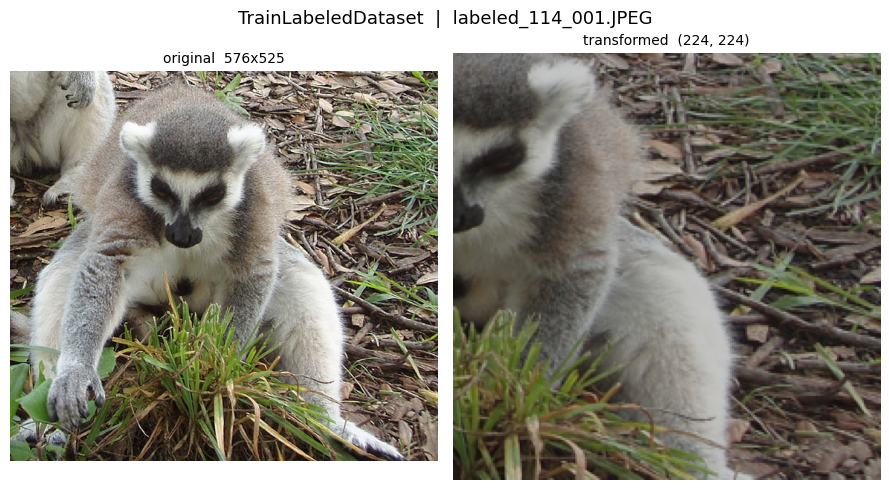

In [3]:
# --- TrainLabeledDataset: image + class_id + filename --------------------------
idx = random.randint(0, 7501)

ds = TrainLabeledDataset(DATA_ROOT, image_transform(train=True))
img_t, label = ds[idx]
name = ds.img_names[idx]
raw = Image.open(ds.items[idx]["image"]).convert("RGB")  # pre-transform

info = CLASS_BY_ID.get(label, {})
show_panels(
    [(f"original  {raw.size[0]}x{raw.size[1]}", raw),
     (f"transformed  {tuple(img_t.shape[1:])}", denormalize(img_t))],
    suptitle=f"TrainLabeledDataset  |  {name}",
    info_lines=[
        f"items         : {len(ds)}",
        f"filename      : {name}",
        f"class_id      : {label}  (name {info.get('name', '?')}, seg_id {info.get('segmentation_id', '?')})",
        f"original size : {raw.size} (W,H)   transformed: {tuple(img_t.shape)} {img_t.dtype}",
    ],
)

items          : 3000
filename       : seg_058_003.JPEG
segmentation_id: 59  (class ?, name ?)
original size  : (500, 375) (W,H)   transformed: (3, 224, 224) / mask (224, 224)
seg ids in mask: [ 0 59]


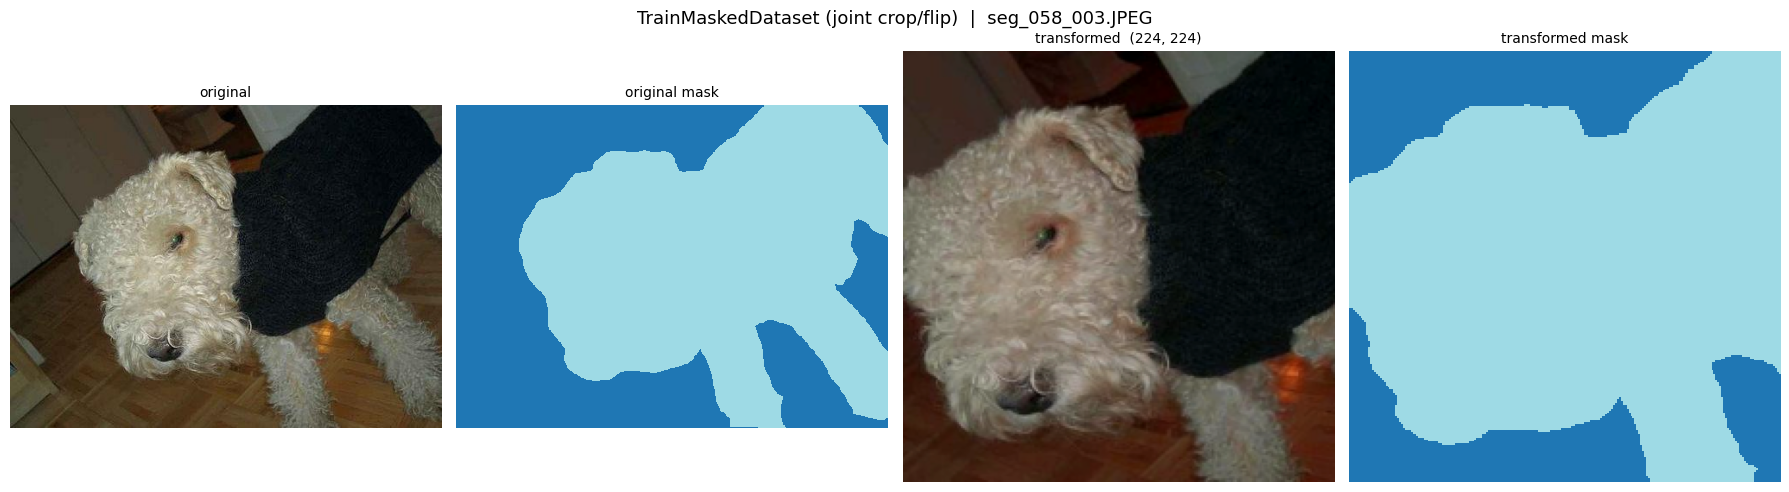

In [4]:
# --- TrainMaskedDataset: image + mask + segmentation_id (JOINT transform) ------
# seg_transform crops/flips the image and mask TOGETHER (nearest on the mask),
# so the foreground stays aligned and seg ids are never blended.
idx = random.randint(0, 3001)

ds = TrainMaskedDataset(DATA_ROOT, seg_transform(train=True))
img_t, mask_t, seg_label = ds[idx]
name = ds.img_names[idx]
item = ds.items[idx]
raw = Image.open(item["image"]).convert("RGB")
raw_mask = rgb_to_seg(np.array(Image.open(DATA_ROOT / item["mask"]).convert("RGB")))

info = CLASS_BY_SEGID.get(seg_label, {})
show_panels(
    [("original", raw),
     ("original mask", raw_mask),
     (f"transformed  {tuple(img_t.shape[1:])}", denormalize(img_t)),
     ("transformed mask", mask_t.numpy())],
    suptitle=f"TrainMaskedDataset (joint crop/flip)  |  {name}",
    info_lines=[
        f"items          : {len(ds)}",
        f"filename       : {name}",
        f"segmentation_id: {seg_label}  (class {info.get('class_id', '?')}, name {info.get('name', '?')})",
        f"original size  : {raw.size} (W,H)   transformed: {tuple(img_t.shape)} / mask {tuple(mask_t.shape)}",
        f"seg ids in mask: {np.unique(mask_t.numpy())}",
    ],
)

items         : 50000
filename      : unlabeled_012255.JPEG  (no label -- pooled for FCMAE pre-training)
original size : (500, 333) (W,H)   transformed: (3, 224, 224) torch.float32


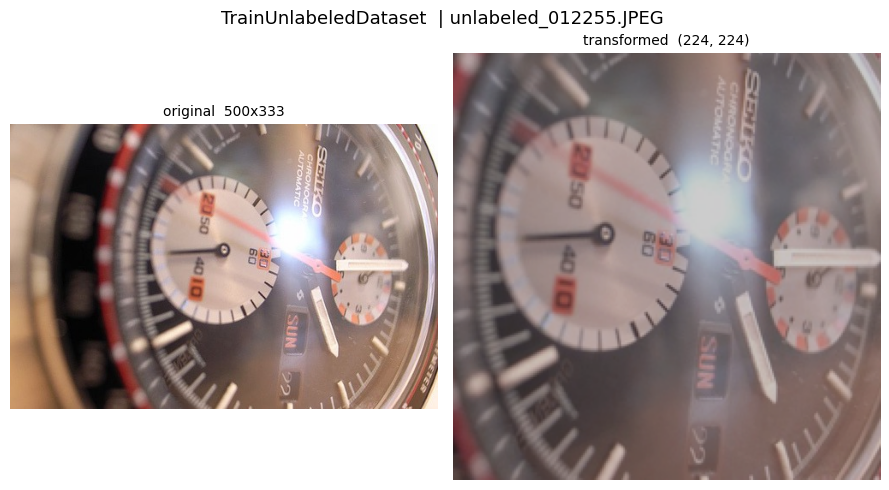

In [5]:
# --- TrainUnlabeledSet: image + filename (no label) ----------------------------
idx = random.randint(0, 50001)

ds = TrainUnlabeledSet(DATA_ROOT, image_transform(train=True))
img_t = ds[idx]
name = ds.img_names[idx]
raw = Image.open(ds.items[idx]["image"]).convert("RGB")  # items hold full paths here

show_panels(
    [(f"original  {raw.size[0]}x{raw.size[1]}", raw),
     (f"transformed  {tuple(img_t.shape[1:])}", denormalize(img_t))],
    suptitle=f"TrainUnlabeledDataset  | {name} ",
    info_lines=[
        f"items         : {len(ds)}",
        f"filename      : {name}  (no label -- pooled for FCMAE pre-training)",
        f"original size : {raw.size} (W,H)   transformed: {tuple(img_t.shape)} {img_t.dtype}",
    ],
)

items         : 750
filename      : val_00000.JPEG
class_id      : 0  (name ?)
orig size     : tensor([500, 375]) (W,H)   image -> (3, 224, 224)   mask stays (375, 500) (H,W)
seg ids in GT : [0 1]


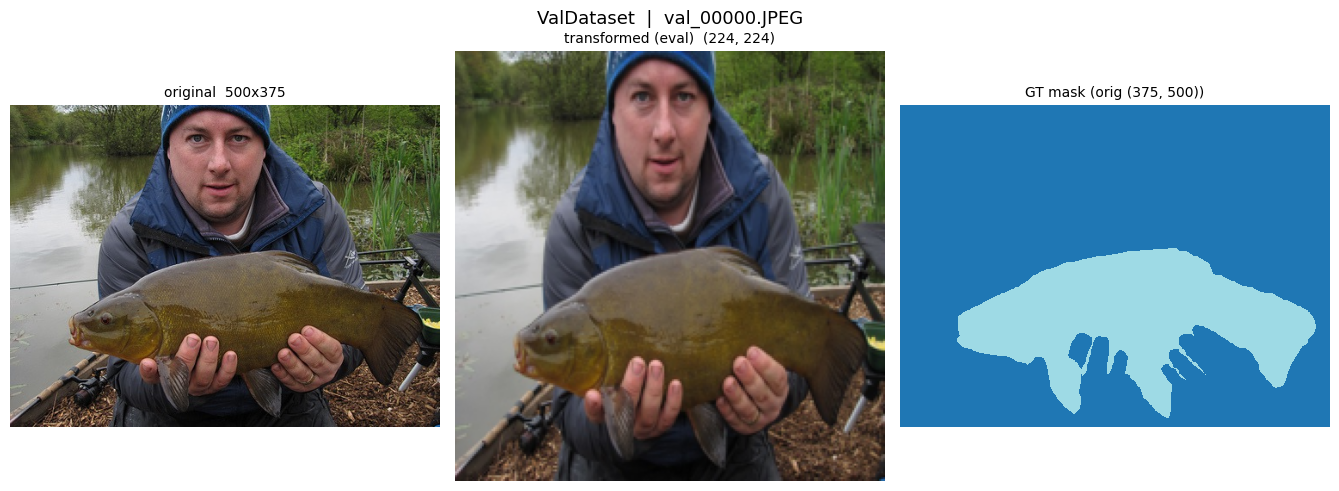

In [6]:
# --- ValDataset: image + GT mask (orig res) + class_id + name + orig size ------
# Eval transform = deterministic resize (no aug). The GT mask is deliberately
# kept at ORIGINAL resolution so val scoring stays exact -- at inference we
# resize the PREDICTION back up (nearest) to compare, never shrink the mask.
idx = 0

ds = ValDataset(DATA_ROOT, image_transform(train=False))
img_t, seg_mask, cls_label, orig_size = ds[idx]
name = ds.img_names[idx]
raw = Image.open(DATA_ROOT / "val" / "images" / name).convert("RGB")

info = CLASS_BY_ID.get(cls_label, {})
show_panels(
    [(f"original  {orig_size[0]}x{orig_size[1]}", raw),
     (f"transformed (eval)  {tuple(img_t.shape[1:])}", denormalize(img_t)),
     (f"GT mask (orig {tuple(seg_mask.shape)})", seg_mask.numpy())],
    suptitle=f"ValDataset  |  {name}",
    info_lines=[
        f"items         : {len(ds)}",
        f"filename      : {name}",
        f"class_id      : {cls_label}  (name {info.get('name', '?')})",
        f"orig size     : {orig_size} (W,H)   image -> {tuple(img_t.shape)}   mask stays {tuple(seg_mask.shape)} (H,W)",
        f"seg ids in GT : {np.unique(seg_mask.numpy())}",
    ],
)

items         : 3000
filename      : test_00958.JPEG
orig size     : tensor([500, 388]) (W,H) -- predictions must be resized back to this
transformed   : (3, 224, 224) torch.float32


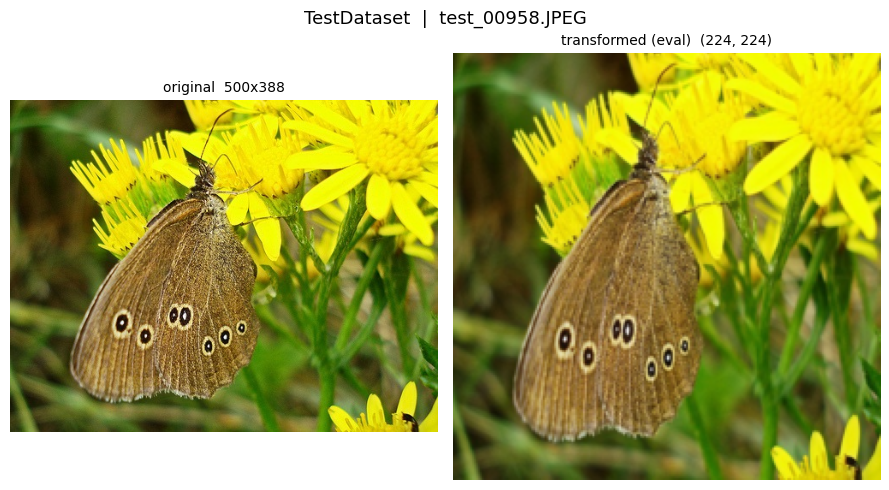

In [7]:
# --- TestDataset: image + filename + orig size (no labels/masks) ---------------
# Eval transform (deterministic resize). orig_size is what predictions must be
# resized back to (nearest) for a valid submission.
idx = random.randint(0, 3001)

ds = TestDataset(DATA_ROOT, image_transform(train=False))
img_t, orig_size = ds[idx]
name = ds.img_names[idx]
raw = Image.open(ds.items[idx]["image"]).convert("RGB")  # items hold full paths

show_panels(
    [(f"original  {orig_size[0]}x{orig_size[1]}", raw),
     (f"transformed (eval)  {tuple(img_t.shape[1:])}", denormalize(img_t))],
    suptitle=f"TestDataset  |  {name}",
    info_lines=[
        f"items         : {len(ds)}",
        f"filename      : {name}",
        f"orig size     : {orig_size} (W,H) -- predictions must be resized back to this",
        f"transformed   : {tuple(img_t.shape)} {img_t.dtype}",
    ],
)

pooled items  : 60500  (50000 unlabeled + 7500 labeled + 3000 seg, labels/masks dropped)
filename      : test_00958.JPEG  (no label -- FCMAE pre-training pool)
original size : (640, 418) (W,H)   transformed: (3, 224, 224) torch.float32


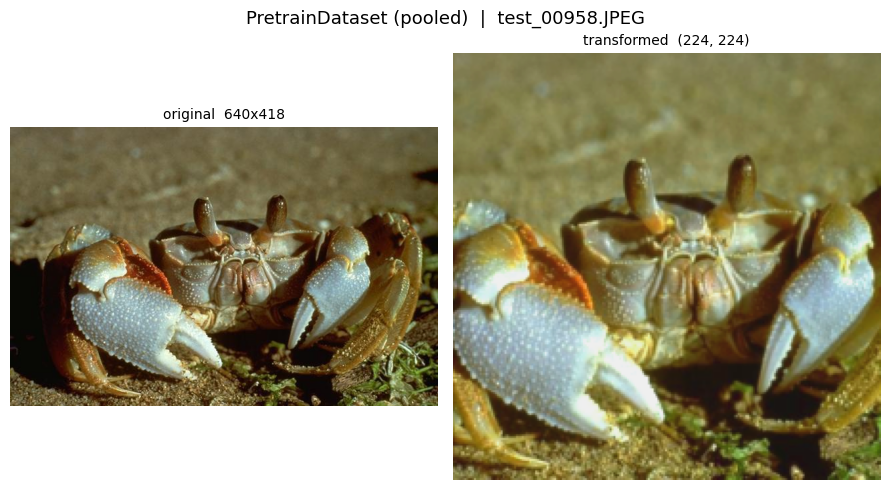

In [8]:
# --- PretrainDataset: pooled image-only set for FCMAE pre-training -------------
# Concatenates train_unlabeled with the items of any datasets you pass (labels
# and masks dropped) into one big image-only pool. Inherits TrainUnlabeledSet,
# so it yields (image, filename).
#
# NOTE: only the unlabeled portion is currently indexable -- pooled labeled/seg
# items keep their data_root-RELATIVE "image" path while __getitem__ opens
# item["image"] directly, so indexing into that portion (idx >= n_unlabeled)
# raises FileNotFoundError. Keep idx in the unlabeled portion; path normalization
# is a known TODO. (Smoke-tested: ds[0] ok, ds[50000] -> FileNotFoundError.)
idx = random.randint(0, 60501)

pooled = [TrainLabeledDataset(DATA_ROOT, image_transform(train=True)),
          TrainMaskedDataset(DATA_ROOT, seg_transform(train=True))]
ds = PretrainDataset(DATA_ROOT, image_transform(train=True), pooled)
n_unlabeled = len(ds) - sum(len(d) for d in pooled)

img_t = ds[idx]
names = ds.img_names[idx]
raw = Image.open(ds.items[idx]["image"]).convert("RGB")  # unlabeled items hold full paths

show_panels(
    [(f"original  {raw.size[0]}x{raw.size[1]}", raw),
     (f"transformed  {tuple(img_t.shape[1:])}", denormalize(img_t))],
    suptitle=f"PretrainDataset (pooled)  |  {name}",
    info_lines=[
        f"pooled items  : {len(ds)}  ({n_unlabeled} unlabeled + "
        f"{len(pooled[0])} labeled + {len(pooled[1])} seg, labels/masks dropped)",
        f"filename      : {name}  (no label -- FCMAE pre-training pool)",
        f"original size : {raw.size} (W,H)   transformed: {tuple(img_t.shape)} {img_t.dtype}",
    ],
)

### models/
- verify that models are loading and unloading correctly
- verify that models are processing correctly (pass in a dummy image, check for the dimensions that we are expecting)
- set hyperparameters

In [9]:
# TODO

### environment
- check cuda/gpu
- set batch size for best performance - max flops!

#### cuda test

In [10]:
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

CUDA available: True


### train engine
- check implementation of training loop
- set 

In [11]:
from src.engines import convnext_cls as cls
import src.models.convnext.convnextv2 as cnv2

model = cnv2.convnextv2_atto()
device = coreutil.get_device()

model.to(device)
ds = TrainLabeledDataset(DATA_ROOT, image_transform(train=True))
data_loader = torch.utils.data.DataLoader(ds, batch_size=20)

cls.predict_one(data_loader, model, device)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Current iteration: 10, Average Loss: 5.70095157623291
Current iteration: 20, Average Loss: 5.730771541595459
Current iteration: 30, Average Loss: 5.729440689086914
Current iteration: 40, Average Loss: 5.752856731414795
Current iteration: 50, Average Loss: 5.760969638824463
Current iteration: 60, Average Loss: 5.771500110626221
Current iteration: 70, Average Loss: 5.781634330749512
Current iteration: 80, Average Loss: 5.782062530517578
Current iteration: 90, Average Loss: 5.782353401184082
Current iteration: 100, Average Loss: 5.7728776931762695
Current iteration: 110, Average Loss: 5.777641296386719
Current iteration: 120, Average Loss: 5.783661365509033
Current iteration: 130, Average Loss: 5.784526348114014
Current iteration: 140, Average Loss: 5.786400318145752
Current iteration: 150, Average Loss: 5.78065824508667
Current iteration: 160, Average Loss: 5.776960849761963
Current iteration: 170, Average Loss: 5.77579927444458
Current iteration: 180, Average Loss: 5.774618148803711
Cur

{'accuracy': tensor(0., device='cuda:0'),
 'loss': tensor(5.7685, device='cuda:0')}

In [12]:
import src.runners.pretrain as pretrainrun

pretrainrun.runner()

AttributeError: 'SparseLinear' object has no attribute 'bias'